# **CNN Model Training**

In [1]:
import tensorflow as tf

print("TF version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

# Enable memory growth to prevent OOM crashes
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"Memory growth enabled on {len(gpus)} GPU(s)")



TF version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Memory growth enabled on 1 GPU(s)


In [7]:
import zipfile
import os
from google.colab import drive

# Mount Drive — a link will appear, click it, sign in, paste the code
drive.mount('/content/drive')

# Change this path to where your zip is located in Drive
ZIP_PATH   = "/content/drive/MyDrive/Dataset.zip"   # <- edit if needed
EXTRACT_TO = "/content/Dataset"

print(f"\nExtracting '{ZIP_PATH}' to '{EXTRACT_TO}' ...")

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_TO)

print("Extraction complete! Folder structure:")
for root, dirs, files_list in os.walk(EXTRACT_TO):
    depth = root.replace(EXTRACT_TO, "").count(os.sep)
    if depth > 2:
        continue
    indent = "  " * depth
    print(f"{indent}{os.path.basename(root)}/")
    for f in files_list[:3]:
        print(f"{indent}  {f}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Extracting '/content/drive/MyDrive/Dataset.zip' to '/content/Dataset' ...
Extraction complete! Folder structure:
Dataset/
  Dataset/
    Video/
    Image/


In [8]:
IMG_SIZE   = 224
BATCH_SIZE = 32      # Safe for T4 16GB VRAM
EPOCHS     = 10
MAX_VIDEOS = 500    # Full 1000 videos per class — generator loads on-the-fly
FRAME_SKIP = 30      # 1 frame every 10 (matches original code)
AUTOTUNE   = tf.data.AUTOTUNE

IMAGE_DIR  = "/content/Dataset/Dataset/Image"
VIDEO_REAL = "/content/Dataset/Dataset/Video/Real"
VIDEO_FAKE = "/content/Dataset/Dataset/Video/Fake"
MODEL_PATH = "/content/Dataset/Dataset/deepfake_model.h5"

print(f"Config ready | IMG:{IMG_SIZE} BATCH:{BATCH_SIZE} EPOCHS:{EPOCHS} MAX_VIDEOS:{MAX_VIDEOS}")



Config ready | IMG:224 BATCH:32 EPOCHS:10 MAX_VIDEOS:500


In [9]:
def build_image_datasets(image_dir, img_size, batch_size):
    common = dict(
        directory        = image_dir,
        validation_split = 0.2,
        seed             = 123,
        image_size       = (img_size, img_size),
        batch_size       = batch_size,
    )
    train = tf.keras.preprocessing.image_dataset_from_directory(
        subset="training", **common)
    val   = tf.keras.preprocessing.image_dataset_from_directory(
        subset="validation", **common)
    return train, val

image_train_ds, image_val_ds = build_image_datasets(IMAGE_DIR, IMG_SIZE, BATCH_SIZE)
print("Image class names:", image_train_ds.class_names)


Found 57071 files belonging to 2 classes.
Using 45657 files for training.
Found 57071 files belonging to 2 classes.
Using 11414 files for validation.
Image class names: ['Fake', 'Real']


In [10]:
# ── CELL 5: Extract frames to disk, load as TF dataset ────
import cv2
import numpy as np
import gc
import os

FRAMES_DIR = "/content/Dataset/Dataset/frames"
os.makedirs(FRAMES_DIR + "/0", exist_ok=True)  # Real
os.makedirs(FRAMES_DIR + "/1", exist_ok=True)  # Fake

def extract_frames_to_disk(real_folder, fake_folder,
                            max_videos=MAX_VIDEOS,
                            frame_skip=FRAME_SKIP,
                            img_size=IMG_SIZE):
    EXT = ('.mp4', '.avi', '.mov', '.mkv')
    total = 0

    for folder, label in [(real_folder, 0), (fake_folder, 1)]:
        videos = sorted([
            v for v in os.listdir(folder)
            if v.lower().endswith(EXT)
        ])[:max_videos]

        print(f"  {'Real' if label==0 else 'Fake'}: {len(videos)} videos...")

        for i, video in enumerate(videos):
            path  = os.path.join(folder, video)
            cap   = cv2.VideoCapture(path)
            count = 0

            while cap.isOpened():
                ret, frame = cap.read()
                if not ret:
                    break
                if count % frame_skip == 0:
                    frame = cv2.resize(frame, (img_size, img_size))
                    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                    # Save as JPEG to disk — uses almost zero RAM
                    save_path = f"{FRAMES_DIR}/{label}/v{i:04d}_f{count:06d}.jpg"
                    cv2.imwrite(save_path, cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))
                    total += 1
                count += 1

            cap.release()

        print(f"    Done. Frames saved: {total}")
        gc.collect()

    print(f"\nAll frames saved to disk. Total: {total}")

print("Extracting frames to disk (one time only)...")
extract_frames_to_disk(VIDEO_REAL, VIDEO_FAKE)

# Load directly from disk using Keras — no RAM bloat at all
video_ds_full = tf.keras.preprocessing.image_dataset_from_directory(
    FRAMES_DIR,
    image_size  = (IMG_SIZE, IMG_SIZE),
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    seed        = 42,
    label_mode  = "int"
)

# Normalize
# No cache — reads from disk each epoch (still fast enough)
video_ds = (video_ds_full
            .map(lambda x, y: (tf.cast(x, tf.float32) / 255.0,
                               tf.cast(y, tf.int32)),
                 num_parallel_calls=AUTOTUNE)
            .prefetch(AUTOTUNE))  # ✅ prefetch only

print("Video dataset ready — disk-based, cached after first epoch.")

Extracting frames to disk (one time only)...
  Real: 500 videos...
    Done. Frames saved: 8976
  Fake: 500 videos...
    Done. Frames saved: 17952

All frames saved to disk. Total: 17952
Found 17952 files belonging to 2 classes.
Video dataset ready — disk-based, cached after first epoch.


In [11]:
def normalize_and_merge(image_ds, video_ds, autotune):
    image_ds = (image_ds
                .map(lambda x, y: (tf.cast(x, tf.float32) / 255.0,
                                   tf.cast(y, tf.int32)),
                     num_parallel_calls=autotune)
                .prefetch(autotune))
    return image_ds.concatenate(video_ds)

train_ds = normalize_and_merge(image_train_ds, video_ds, AUTOTUNE)

val_ds = (image_val_ds
          .map(lambda x, y: (tf.cast(x, tf.float32) / 255.0,
                             tf.cast(y, tf.int32)),
               num_parallel_calls=AUTOTUNE)
          .prefetch(AUTOTUNE))  # ✅ no .cache() here either

print("Train + val datasets merged.")


Train + val datasets merged.


In [12]:
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2

def build_model(img_size):
    base = MobileNetV2(
        input_shape=(img_size, img_size, 3),
        include_top=False,
        weights="imagenet"
    )
    base.trainable = False  # Freeze base (Phase 1)

    inputs = tf.keras.Input(shape=(img_size, img_size, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    x = layers.BatchNormalization()(x)
    output = layers.Dense(1, activation="sigmoid")(x)

    model = Model(inputs, output)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy",
                 tf.keras.metrics.AUC(name="auc"),
                 tf.keras.metrics.Precision(name="precision"),
                 tf.keras.metrics.Recall(name="recall")]
    )
    return model, base

model, base_model = build_model(IMG_SIZE)
model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,593 (9.24 MB)

 Trainable params: 164,353 (642.00 KB)

 Non-trainable params: 2,258,240 (8.61 MB)

In [13]:
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                         ModelCheckpoint)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=3,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=2, min_lr=1e-7, verbose=1),
    ModelCheckpoint(MODEL_PATH, save_best_only=True,
                    monitor="val_accuracy", verbose=1),
]



In [14]:
print("\n===== PHASE 1: Training classifier head =====")
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)



===== PHASE 1: Training classifier head =====
Epoch 1/10
1987/1988 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.9139 - auc: 0.9701 - loss: 0.1965 - precision: 0.9069 - recall: 0.9230
Epoch 1: val_accuracy improved from None to 0.76590, saving model to /content/Dataset/Dataset/deepfake_model.h5



Epoch 1: finished saving model to /content/Dataset/Dataset/deepfake_model.h5
1988/1988 ━━━━━━━━━━━━━━━━━━━━ 637s 309ms/step - accuracy: 0.8340 - auc: 0.9371 - loss: 0.3063 - precision: 0.8335 - recall: 0.8341 - val_accuracy: 0.7659 - val_auc: 0.9973 - val_loss: 0.3760 - val_precision: 0.6808 - val_recall: 0.9998 - learning_rate: 1.0000e-04
Epoch 2/10
1987/1988 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.9591 - auc: 0.9919 - loss: 0.1123 - precision: 0.9616 - recall: 0.9565
Epoch 2: val_accuracy improved from 0.76590 to 0.92842, saving model to /content/Dataset/Dataset/deepfake_model.h5



Epoch 2: finished saving model to /content/Dataset/Dataset/deepfake_model.h5
1988/1988 ━━━━━━━━━━━━━━━━━━━━ 595s 299ms/step - accuracy: 0.8542 - auc: 0.9525 - loss: 0.2607 - precision: 0.8515 - recall: 0.8575 - val_accuracy: 0.9284 - val_auc: 0.9979 - val_loss: 0.2004 - val_precision: 0.8752 - val_recall: 0.9991 - learning_rate: 1.0000e-04
Epoch 3/10
1988/1988 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.9640 - auc: 0.9934 - loss: 0.0907 - precision: 0.9683 - recall: 0.9597
Epoch 3: val_accuracy did not improve from 0.92842
1988/1988 ━━━━━━━━━━━━━━━━━━━━ 566s 285ms/step - accuracy: 0.8577 - auc: 0.9563 - loss: 0.2444 - precision: 0.8550 - recall: 0.8609 - val_accuracy: 0.8551 - val_auc: 0.9961 - val_loss: 0.3011 - val_precision: 0.7751 - val_recall: 0.9998 - learning_rate: 1.0000e-04
Epoch 4/10
1987/1988 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.9657 - auc: 0.9941 - loss: 0.0822 - precision: 0.9693 - recall: 0.9621
Epoch 4: val_accuracy improved from 0.92842 to 0.94034, sav


Epoch 4: finished saving model to /content/Dataset/Dataset/deepfake_model.h5
1988/1988 ━━━━━━━━━━━━━━━━━━━━ 562s 283ms/step - accuracy: 0.8607 - auc: 0.9582 - loss: 0.2369 - precision: 0.8569 - recall: 0.8656 - val_accuracy: 0.9403 - val_auc: 0.9972 - val_loss: 0.1678 - val_precision: 0.8934 - val_recall: 0.9998 - learning_rate: 1.0000e-04
Epoch 5/10
1988/1988 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.9667 - auc: 0.9943 - loss: 0.0776 - precision: 0.9707 - recall: 0.9627
Epoch 5: val_accuracy improved from 0.94034 to 0.95470, saving model to /content/Dataset/Dataset/deepfake_model.h5



Epoch 5: finished saving model to /content/Dataset/Dataset/deepfake_model.h5
1988/1988 ━━━━━━━━━━━━━━━━━━━━ 563s 283ms/step - accuracy: 0.8631 - auc: 0.9597 - loss: 0.2311 - precision: 0.8586 - recall: 0.8687 - val_accuracy: 0.9547 - val_auc: 0.9956 - val_loss: 0.1860 - val_precision: 0.9169 - val_recall: 0.9998 - learning_rate: 1.0000e-04
Epoch 6/10
1987/1988 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.9674 - auc: 0.9942 - loss: 0.0779 - precision: 0.9715 - recall: 0.9634
Epoch 6: val_accuracy improved from 0.95470 to 0.96837, saving model to /content/Dataset/Dataset/deepfake_model.h5



Epoch 6: finished saving model to /content/Dataset/Dataset/deepfake_model.h5
1988/1988 ━━━━━━━━━━━━━━━━━━━━ 565s 284ms/step - accuracy: 0.8664 - auc: 0.9604 - loss: 0.2304 - precision: 0.8626 - recall: 0.8712 - val_accuracy: 0.9684 - val_auc: 0.9941 - val_loss: 0.1600 - val_precision: 0.9407 - val_recall: 0.9996 - learning_rate: 1.0000e-04
Epoch 7/10
1988/1988 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.9680 - auc: 0.9946 - loss: 0.0721 - precision: 0.9714 - recall: 0.9648
Epoch 7: val_accuracy improved from 0.96837 to 0.98300, saving model to /content/Dataset/Dataset/deepfake_model.h5



Epoch 7: finished saving model to /content/Dataset/Dataset/deepfake_model.h5
1988/1988 ━━━━━━━━━━━━━━━━━━━━ 562s 283ms/step - accuracy: 0.8671 - auc: 0.9616 - loss: 0.2248 - precision: 0.8615 - recall: 0.8743 - val_accuracy: 0.9830 - val_auc: 0.9971 - val_loss: 0.0947 - val_precision: 0.9679 - val_recall: 0.9991 - learning_rate: 1.0000e-04
Epoch 8/10
1987/1988 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.9683 - auc: 0.9950 - loss: 0.0697 - precision: 0.9724 - recall: 0.9644
Epoch 8: val_accuracy did not improve from 0.98300
1988/1988 ━━━━━━━━━━━━━━━━━━━━ 564s 284ms/step - accuracy: 0.8713 - auc: 0.9632 - loss: 0.2218 - precision: 0.8656 - recall: 0.8787 - val_accuracy: 0.9728 - val_auc: 0.9939 - val_loss: 0.1534 - val_precision: 0.9485 - val_recall: 0.9998 - learning_rate: 1.0000e-04
Epoch 9/10
1988/1988 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.9693 - auc: 0.9951 - loss: 0.0680 - precision: 0.9723 - recall: 0.9666
Epoch 9: ReduceLROnPlateau reducing learning rate to 4.9999

In [15]:
print("\n===== PHASE 2: Fine-tuning top 30 layers =====")
base_model.trainable = True

# Freeze all except the top 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy",
             tf.keras.metrics.AUC(name="auc"),
             tf.keras.metrics.Precision(name="precision"),
             tf.keras.metrics.Recall(name="recall")]
)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=callbacks,
    verbose=1,
)



===== PHASE 2: Fine-tuning top 30 layers =====
Epoch 1/5
1988/1988 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.9427 - auc: 0.9880 - loss: 0.1440 - precision: 0.9688 - recall: 0.9154
Epoch 1: val_accuracy did not improve from 0.98300
1988/1988 ━━━━━━━━━━━━━━━━━━━━ 617s 299ms/step - accuracy: 0.8600 - auc: 0.9486 - loss: 0.2974 - precision: 0.8680 - recall: 0.8486 - val_accuracy: 0.9770 - val_auc: 0.9956 - val_loss: 0.0724 - val_precision: 0.9685 - val_recall: 0.9861 - learning_rate: 1.0000e-05
Epoch 2/5
1988/1988 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.9691 - auc: 0.9941 - loss: 0.1000 - precision: 0.9725 - recall: 0.9656
Epoch 2: val_accuracy improved from 0.98300 to 0.98423, saving model to /content/Dataset/Dataset/deepfake_model.h5



Epoch 2: finished saving model to /content/Dataset/Dataset/deepfake_model.h5
1988/1988 ━━━━━━━━━━━━━━━━━━━━ 580s 292ms/step - accuracy: 0.8844 - auc: 0.9641 - loss: 0.2385 - precision: 0.8844 - recall: 0.8839 - val_accuracy: 0.9842 - val_auc: 0.9972 - val_loss: 0.0542 - val_precision: 0.9757 - val_recall: 0.9932 - learning_rate: 1.0000e-05
Epoch 3/5
1987/1988 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.9756 - auc: 0.9961 - loss: 0.0751 - precision: 0.9786 - recall: 0.9725
Epoch 3: val_accuracy improved from 0.98423 to 0.98800, saving model to /content/Dataset/Dataset/deepfake_model.h5



Epoch 3: finished saving model to /content/Dataset/Dataset/deepfake_model.h5
1988/1988 ━━━━━━━━━━━━━━━━━━━━ 575s 289ms/step - accuracy: 0.9013 - auc: 0.9735 - loss: 0.2047 - precision: 0.9003 - recall: 0.9021 - val_accuracy: 0.9880 - val_auc: 0.9975 - val_loss: 0.0442 - val_precision: 0.9805 - val_recall: 0.9958 - learning_rate: 1.0000e-05
Epoch 4/5
1987/1988 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.9786 - auc: 0.9971 - loss: 0.0609 - precision: 0.9825 - recall: 0.9746
Epoch 4: val_accuracy improved from 0.98800 to 0.99115, saving model to /content/Dataset/Dataset/deepfake_model.h5



Epoch 4: finished saving model to /content/Dataset/Dataset/deepfake_model.h5
1988/1988 ━━━━━━━━━━━━━━━━━━━━ 576s 290ms/step - accuracy: 0.9116 - auc: 0.9791 - loss: 0.1814 - precision: 0.9114 - recall: 0.9114 - val_accuracy: 0.9912 - val_auc: 0.9977 - val_loss: 0.0369 - val_precision: 0.9858 - val_recall: 0.9967 - learning_rate: 1.0000e-05
Epoch 5/5
1988/1988 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.9818 - auc: 0.9977 - loss: 0.0508 - precision: 0.9848 - recall: 0.9786
Epoch 5: val_accuracy did not improve from 0.99115
1988/1988 ━━━━━━━━━━━━━━━━━━━━ 572s 288ms/step - accuracy: 0.9225 - auc: 0.9832 - loss: 0.1630 - precision: 0.9249 - recall: 0.9194 - val_accuracy: 0.9903 - val_auc: 0.9979 - val_loss: 0.0414 - val_precision: 0.9842 - val_recall: 0.9965 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 4.


# **Evalution Accuracy**

In [16]:
print("\n===== FINAL EVALUATION ON VALIDATION SET =====")
results = model.evaluate(val_ds, verbose=1)
metric_names = model.metrics_names

print("\n--- Test Results ---")
for name, val in zip(metric_names, results):
    print(f"  {name:12s}: {val:.4f}")

loss      = results[0]
accuracy  = results[1]
auc       = results[2]
precision = results[3]
recall    = results[4]
f1        = 2 * (precision * recall) / (precision + recall + 1e-8)

print(f"\n  {'F1 Score':12s}: {f1:.4f}")
print("-----------------------------------")
print(f"\nFinal Test Accuracy : {accuracy*100:.2f}%")
print(f"AUC Score           : {auc:.4f}")
print(f"F1 Score            : {f1:.4f}")



===== FINAL EVALUATION ON VALIDATION SET =====
357/357 ━━━━━━━━━━━━━━━━━━━━ 111s 310ms/step - accuracy: 0.9912 - auc: 0.9977 - loss: 0.0369 - precision: 0.9858 - recall: 0.9967

--- Test Results ---
  loss        : 0.0369
  compile_metrics: 0.9912

  F1 Score    : 0.9912
-----------------------------------

Final Test Accuracy : 99.12%
AUC Score           : 0.9977
F1 Score            : 0.9912


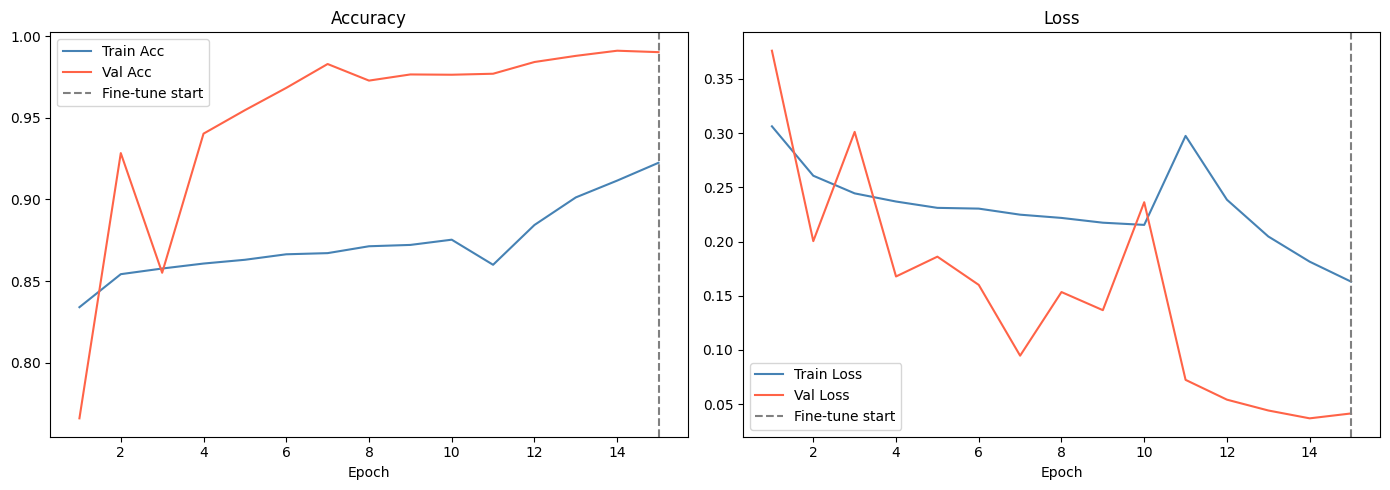

Plot saved to /content/Dataset/Datasettraining_curves.png


In [17]:
import matplotlib.pyplot as plt

def plot_history(h1, h2=None):
    acc   = h1.history['accuracy']
    vacc  = h1.history['val_accuracy']
    loss  = h1.history['loss']
    vloss = h1.history['val_loss']

    if h2:
        acc   += h2.history['accuracy']
        vacc  += h2.history['val_accuracy']
        loss  += h2.history['loss']
        vloss += h2.history['val_loss']

    epochs_range = range(1, len(acc) + 1)
    phase_split  = len(h1.history['accuracy'])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs_range, acc,  label='Train Acc',  color='steelblue')
    ax1.plot(epochs_range, vacc, label='Val Acc',    color='tomato')
    if h2:
        ax1.axvline(phase_split, linestyle='--', color='gray', label='Fine-tune start')
    ax1.set_title('Accuracy'); ax1.legend(); ax1.set_xlabel('Epoch')

    ax2.plot(epochs_range, loss,  label='Train Loss', color='steelblue')
    ax2.plot(epochs_range, vloss, label='Val Loss',   color='tomato')
    if h2:
        ax2.axvline(phase_split, linestyle='--', color='gray', label='Fine-tune start')
    ax2.set_title('Loss'); ax2.legend(); ax2.set_xlabel('Epoch')

    plt.tight_layout()
    plt.savefig('/content/Dataset/Dataset/training_curves.png', dpi=150)
    plt.show()
    print("Plot saved to /content/Dataset/Datasettraining_curves.png")

plot_history(history1, history2)


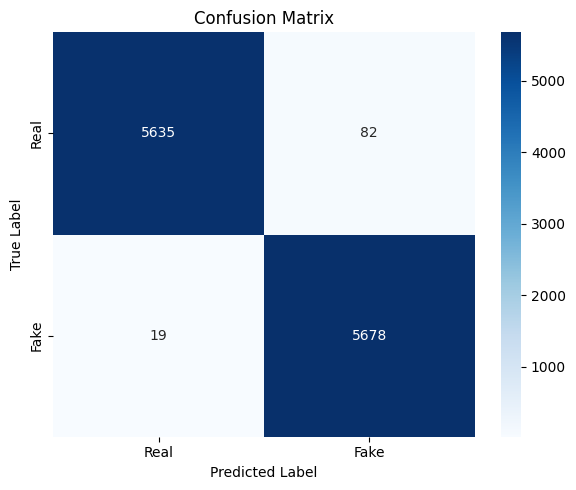


Classification Report:
              precision    recall  f1-score   support

        Real       1.00      0.99      0.99      5717
        Fake       0.99      1.00      0.99      5697

    accuracy                           0.99     11414
   macro avg       0.99      0.99      0.99     11414
weighted avg       0.99      0.99      0.99     11414



In [18]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_true, y_pred_prob = [], []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_pred_prob.extend(preds.flatten().tolist())
    y_true.extend(labels.numpy().tolist())

y_pred = [1 if p >= 0.5 else 0 for p in y_pred_prob]

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/Dataset/Datasetconfusion_matrix.png', dpi=150)
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Real', 'Fake']))


# **Downlaod The Model**

In [19]:
model.save(MODEL_PATH)
print(f"Model saved to: {MODEL_PATH}")

# Download model file to your computer
from google.colab import files
files.download(MODEL_PATH)

Model saved to: /content/Dataset/Dataset/deepfake_model.h5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>